# Cyclones

In [1]:
import xarray as xa
import pandas as pd
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

import cartopy.feature as cfeature
import cartopy.crs as ccrs


# custom
from src.plots import plot_utils
from src import config


fp = config.data_dir / "cyclones" / "cyclones.nc"
cyclones_xa = xa.open_dataset(fp)

Interpolating tracks for 13544 historical storms...


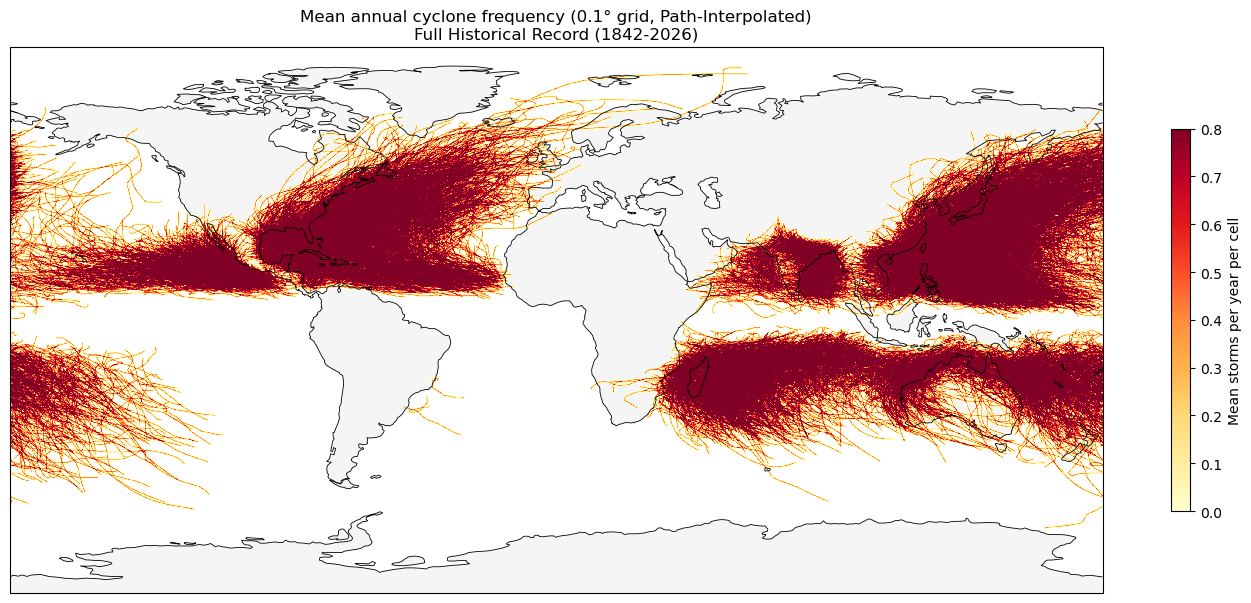

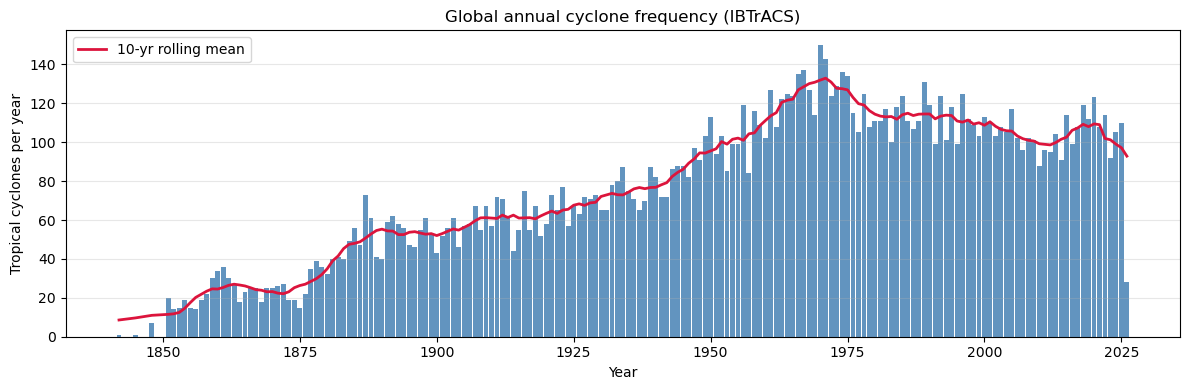

In [2]:
GRID_STEP = 0.1  # degrees (~11 km)

# Prepare dataframe from your xarray object
valid = cyclones_xa.lon.notnull() & cyclones_xa.lat.notnull()
storm_year = cyclones_xa.time.dt.year.where(valid)

track_df = (
    xa.Dataset(
        {
            "year": storm_year,
            "lon": cyclones_xa.lon,
            "lat": cyclones_xa.lat,
            "storm": cyclones_xa.storm,
            "time": cyclones_xa.time,
        }
    )
    .to_dataframe()
    .reset_index()
    .dropna(subset=["year", "lon", "lat", "storm"])
)
track_df["year"] = track_df["year"].astype(int)

print(f"Interpolating tracks for {track_df['storm'].nunique()} historical storms...")


# --- Track Interpolation Function ---
def interpolate_storm_track(group):
    if len(group) < 2:
        return group[["year", "lon", "lat", "storm"]]

    group = group.sort_values("time")
    lons = group["lon"].values
    lats = group["lat"].values

    # Handle International Date Line crossings smoothly
    lons_unwrapped = np.unwrap(lons, period=360)

    interp_lons = []
    interp_lats = []

    for i in range(len(group) - 1):
        lon1, lon2 = lons_unwrapped[i], lons_unwrapped[i + 1]
        lat1, lat2 = lats[i], lats[i + 1]

        # Calculate spatial distance in degrees to determine sub-steps
        dist = np.hypot(lon2 - lon1, lat2 - lat1)

        # Ensure we place points closer together than our 0.1° grid cell size
        n_pts = max(2, int(np.ceil(dist / (GRID_STEP * 0.5))))

        interp_lons.extend(np.linspace(lon1, lon2, n_pts)[:-1])
        interp_lats.extend(np.linspace(lat1, lat2, n_pts)[:-1])

    # Append the final point of the track
    interp_lons.append(lons_unwrapped[-1])
    interp_lats.append(lats[-1])

    # Wrap longitudes back to the standard [-180, 180] range
    interp_lons = (np.array(interp_lons) + 180) % 360 - 180

    return pd.DataFrame(
        {
            "year": group["year"].iloc[0],  # Assign to the storm's origin year
            "lon": interp_lons,
            "lat": interp_lats,
            "storm": group["storm"].iloc[0],
        }
    )


# Run interpolation across all storms (takes a brief moment to process the full history)
interpolated_tracks_list = [
    interpolate_storm_track(grp) for _, grp in track_df.groupby("storm")
]
interp_df = pd.concat(interpolated_tracks_list, ignore_index=True)

# --- Spatial Binning Setup ---
lon_edges = np.arange(-180, 180 + GRID_STEP, GRID_STEP)
lat_edges = np.arange(-90, 90 + GRID_STEP, GRID_STEP)
lon_centers = lon_edges[:-1] + GRID_STEP / 2
lat_centers = lat_edges[:-1] + GRID_STEP / 2

interp_df["lon_i"] = np.clip(
    np.digitize(interp_df["lon"], lon_edges) - 1, 0, len(lon_edges) - 2
)
interp_df["lat_i"] = np.clip(
    np.digitize(interp_df["lat"], lat_edges) - 1, 0, len(lat_edges) - 2
)

# Deduplicate so a single storm only counts once per grid cell, per year
cell_year_storms = interp_df.drop_duplicates(subset=["year", "lat_i", "lon_i", "storm"])

storms_per_cell_year = (
    cell_year_storms.groupby(["year", "lat_i", "lon_i"])
    .size()
    .rename("n_storms")
    .reset_index()
)

mean_annual_by_cell = storms_per_cell_year.groupby(["lat_i", "lon_i"])[
    "n_storms"
].mean()

# Populate the final matrix
mean_grid = np.zeros((len(lat_centers), len(lon_centers)), dtype=float)
for (lat_i, lon_i), value in mean_annual_by_cell.items():
    mean_grid[int(lat_i), int(lon_i)] = value

# --- Light Spatial Filter ---
# Since 19th-century logs are heavily locked to exact integer coordinates, a light
# Gaussian blur (sigma=1.0) eliminates remaining artificial linear spikes.
smoothed_grid = gaussian_filter(mean_grid, sigma=1.0)
smoothed_grid[smoothed_grid < 1e-4] = np.nan

# Rebuild Xarray DataArray
cyclone_freq_annual_mean = xa.DataArray(
    smoothed_grid,
    coords={"lat": lat_centers, "lon": lon_centers},
    dims=["lat", "lon"],
    name="mean_annual_cyclone_count",
    attrs={
        "long_name": "Mean annual tropical cyclone count per grid cell",
        "units": "storms yr-1",
        "grid_step_deg": GRID_STEP,
        "years": f"{int(track_df['year'].min())}-{int(track_df['year'].max())}",
    },
)

# --- Plotting ---
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

mesh = ax.pcolormesh(
    cyclone_freq_annual_mean.lon,
    cyclone_freq_annual_mean.lat,
    cyclone_freq_annual_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=0.8,  # Adjusted scale for interpolated density distribution
    shading="auto",
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
ax.set_global()

plt.colorbar(mesh, ax=ax, label="Mean storms per year per cell", shrink=0.7)
ax.set_title(
    f"Mean annual cyclone frequency ({GRID_STEP}° grid, Path-Interpolated)\n"
    f"Full Historical Record ({cyclone_freq_annual_mean.attrs['years']})"
)
plt.tight_layout()
plt.show()


# --- Global annual frequency: unique storms per calendar year ---
annual_freq = (
    track_df.groupby("year")["storm"].nunique().sort_index().rename("n_storms")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(annual_freq.index, annual_freq.values, color="steelblue", alpha=0.85, width=0.9)
roll = annual_freq.rolling(10, center=True, min_periods=5).mean()
ax.plot(
    roll.index, roll.values, color="crimson", linewidth=2, label="10-yr rolling mean"
)
ax.set_xlabel("Year")
ax.set_ylabel("Tropical cyclones per year")
ax.set_title("Global annual cyclone frequency (IBTrACS)")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# MPAs

Using https://www.protectedplanet.net/en/thematic-areas/wdpa?tab=WDPA

In [3]:
from glob import glob
import geopandas as gpd
from tqdm.auto import tqdm

shapefiles_fps = list(config.mpas_dir.glob("WDPA_*shp*/WDPA_*polygons.shp"))

# open each shapefile as a gdf and concatenate them
mpas_gdf = gpd.GeoDataFrame()
for fp in tqdm(shapefiles_fps):
    mpas_gdf = pd.concat([mpas_gdf, gpd.read_file(fp)])

mpas_gdf.rename(columns=str.lower, inplace=True)
mpas_gdf.head()


  0%|          | 0/3 [00:00<?, ?it/s]

,site_id,site_pid,site_type,name_eng,name,desig,desig_eng,desig_type,iucn_cat,int_crit,...,mang_plan,verif,metadataid,prnt_iso3,iso3,supp_info,cons_obj,inlnd_wtrs,oecm_asmt,geometry
0,555648064,555648064,PA,5-02-490,5-02-490,Open Space Covenant,Open Space Covenant,National,IV,Not Applicable,...,Not Reported,State Verified,1944,NZL,NZL,Not Applicable,Not Applicable,Not Reported,Not Applicable,"POLYGON ((174.4856 -35.72779, 174.48577 -35.72..."
1,555648065,555648065,PA,5-02-491,5-02-491,Open Space Covenant,Open Space Covenant,National,IV,Not Applicable,...,Not Reported,State Verified,1944,NZL,NZL,Not Applicable,Not Applicable,Not Reported,Not Applicable,"POLYGON ((174.20955 -35.25723, 174.21016 -35.2..."
2,555648066,555648066,PA,5-02-526,5-02-526,Open Space Covenant,Open Space Covenant,National,IV,Not Applicable,...,Not Reported,State Verified,1944,NZL,NZL,Not Applicable,Not Applicable,Not Reported,Not Applicable,"POLYGON ((174.47979 -35.76682, 174.48002 -35.7..."
3,555648067,555648067,PA,5-02-529,5-02-529,Open Space Covenant,Open Space Covenant,National,IV,Not Applicable,...,Not Reported,State Verified,1944,NZL,NZL,Not Applicable,Not Applicable,Not Reported,Not Applicable,"MULTIPOLYGON (((173.74614 -35.29146, 173.74655..."
4,555648068,555648068,PA,5-02-532,5-02-532,Open Space Covenant,Open Space Covenant,National,IV,Not Applicable,...,Not Reported,State Verified,1944,NZL,NZL,Not Applicable,Not Applicable,Not Reported,Not Applicable,"POLYGON ((174.31469 -35.66002, 174.31469 -35.6..."


<GeoAxes: >

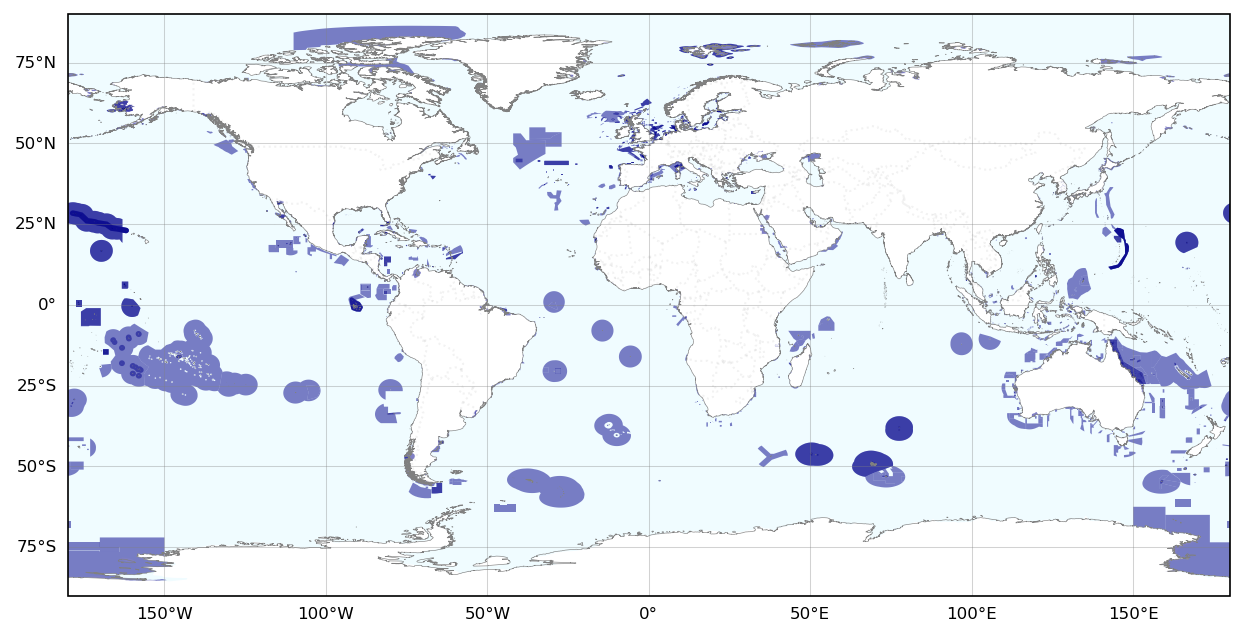

In [4]:
# filter for marine/coastal
mpas_gdf = mpas_gdf[mpas_gdf["realm"].isin(["Marine", "Coastal"])]

fig, ax = plot_utils.generate_geo_axis(
    figsize=(10, 10),
    map_proj=ccrs.PlateCarree(),
    dpi=150,
    central_longitude=0,
    central_latitude=0,
)
plot_utils.format_geo_axes(ax)

mpas_gdf.plot(ax=ax, color="darkblue", alpha=0.5)

In [ ]:
# maybe useful: gov_type/own_type (interesting to investigate which orgs do best)
# ? status_yr, inlnd_wtrs
# iucn_cat is e.g. managed area, monument, national park etc. (https://en.wikipedia.org/wiki/IUCN_protected_area_categories)

# TODO: for now (and likely future): assign points a binary protected/not protected. And look for datasets contextualising the effectiveness of different MPAs

# Population

In [ ]:
# future: https://hub.worldpop.org/geodata/summary?id=110984

# base URL: https://hub.worldpop.org/geodata/summary?id=80021